<a href="https://colab.research.google.com/github/SofiaAlbyt/NM/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22%D0%9B%D0%A013_%D0%90%D0%BB%D1%8C%D0%B1%D0%B8%D1%82_1%D0%B2_%D0%91_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 13.

#Метод Ейлера

x	Ейлер		Ейлер-Коші
1.6	4.6000		4.6000
1.7	4.8599		4.8649
1.8	5.1298		5.1393
1.9	5.4088		5.4225
2.0	5.6962		5.7133
2.1	5.9908		6.0110
2.2	6.2919		6.3144
2.3	6.5983		6.6227
2.4	6.9092		6.9348
2.5	7.2236		7.2499
2.6	7.5406		7.5671


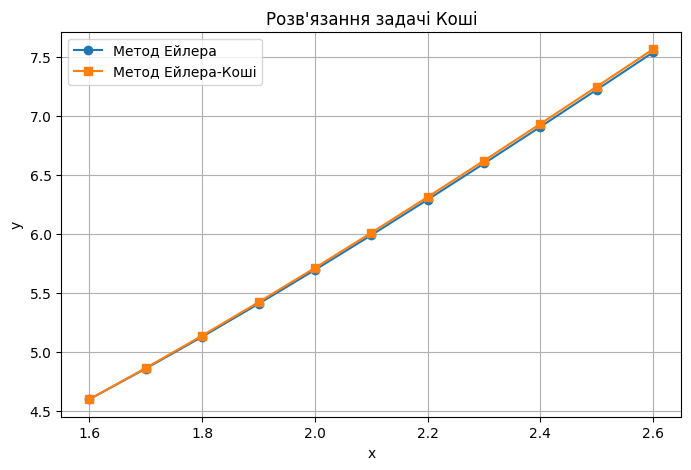

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x + np.sin(y / 3)

a, b = 1.6, 2.6
h = 0.1
y0 = 4.6

n = int((b - a) / h)
x = np.array([a + i * h for i in range(n + 1)])

y_euler = np.empty(n + 1)
y_cauchy = np.empty(n + 1)

y_euler[0] = y0
y_cauchy[0] = y0

for i in range(n):
    y_euler[i + 1] = y_euler[i] + h * f(x[i], y_euler[i])

for i in range(n):
    k1 = f(x[i], y_cauchy[i])
    y_pred = y_cauchy[i] + h * k1
    k2 = f(x[i + 1], y_pred)
    y_cauchy[i + 1] = y_cauchy[i] + h * (k1 + k2) / 2

print("x\tЕйлер\t\tЕйлер-Коші")
for i in range(n + 1):
    print(f"{x[i]:.1f}\t{y_euler[i]:.4f}\t\t{y_cauchy[i]:.4f}")

plt.figure(figsize=(8, 5))

plt.plot(x, y_euler, marker='o', label="Метод Ейлера")
plt.plot(x, y_cauchy, marker='s', label="Метод Ейлера-Коші")

plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Розв'язання задачі Коші")
plt.legend()

plt.show()

In [2]:
# Додати перевірку odeint для першого завдання

import numpy as np
from scipy.integrate import odeint

# Функція з умови
# y' = x + sin(y / 3)
def f_odeint(y, x):
    return x + np.sin(y / 3)

# Початкові дані
a, b = 1.6, 2.6
h = 0.1
y0 = 4.6

# Формування масиву x
n = int((b - a) / h)

x = np.array([a + i * h for i in range(n + 1)])

# Розв'язок за допомогою odeint
y_odeint = odeint(f_odeint, y0, x)[:, 0]

# Округлення
y_odeint_rounded = np.round(y_odeint, 4)

# Виведення результатів
print("Перевірка: odeint")
print()

print("x =", x)
print()
print("y =", y_odeint_rounded)

Перевірка: odeint

x = [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6]

y = [4.6    4.865  5.1395 5.4226 5.7136 6.0113 6.3148 6.6231 6.9353 7.2504
 7.5676]


In [3]:
# Додати перевірку solve_ivp для першого завдання

import numpy as np
from scipy.integrate import solve_ivp

# Функція з умови
# y' = x + sin(y / 3)
def f_solve_ivp(x, y):
    return x + np.sin(y / 3)

# Початкові дані
a, b = 1.6, 2.6
h = 0.1
y0 = 4.6

# Формування масиву x
n = int((b - a) / h)

x_eval = np.array([a + i * h for i in range(n + 1)])

# Розв'язок за допомогою solve_ivp
sol = solve_ivp(
    f_solve_ivp,
    t_span=(a, b),
    y0=[y0],
    t_eval=x_eval
)

# Отримання результатів
y_solve_ivp = sol.y[0]

# Округлення
y_solve_ivp_rounded = np.round(y_solve_ivp, 4)

# Виведення результатів
print("Перевірка: solve_ivp")
print()

print("x =", x_eval)
print()
print("y =", y_solve_ivp_rounded)

Перевірка: solve_ivp

x = [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6]

y = [4.6    4.865  5.1395 5.4227 5.7137 6.0113 6.3148 6.623  6.9352 7.2503
 7.5676]


#Метод Ейлера-Коші

Метод Ейлера-Коші:
x=1.6, y=4.6000
x=1.7, y=4.8649
x=1.8, y=5.1393
x=1.9, y=5.4225
x=2.0, y=5.7133
x=2.1, y=6.0110
x=2.2, y=6.3144
x=2.3, y=6.6227
x=2.4, y=6.9348
x=2.5, y=7.2499
x=2.6, y=7.5671


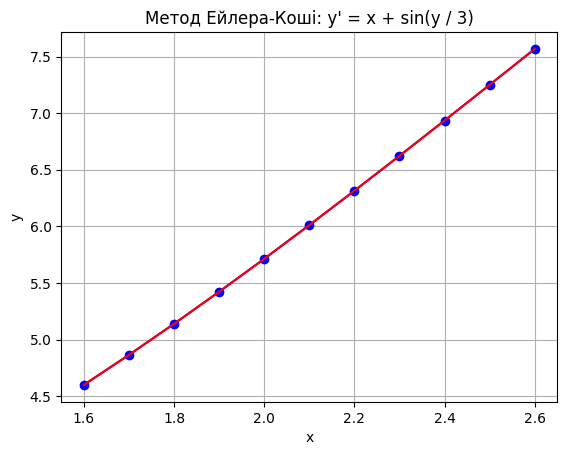

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Функція з умови
# y' = x + sin(y / 3)
def f(x, y):
    return x + np.sin(y / 3)

# Початкові дані
a, b = 1.6, 2.6
h = 0.1
y0 = 4.6

# Формування масиву x
n = int((b - a) / h)

x = np.array([a + i * h for i in range(n + 1)])

# Масив y
y = np.empty(n + 1)
y[0] = y0

# Метод Ейлера-Коші
for i in range(n):

    k1 = f(x[i], y[i])

    # Прогноз
    y_pred = y[i] + h * k1

    k2 = f(x[i] + h, y_pred)

    # Корекція
    y[i + 1] = y[i] + (h / 2) * (k1 + k2)

# Округлення
y_rounded = np.round(y, 4)

# Виведення результатів
print("Метод Ейлера-Коші:")

for i in range(n + 1):
    print(f"x={x[i]:.1f}, y={y_rounded[i]:.4f}")

# Побудова графіка
plt.plot(x, y, marker='o', color="blue")
plt.plot(x, y, "-", color="red")

plt.grid()

plt.title("Метод Ейлера-Коші: y' = x + sin(y / 3)")

plt.xlabel("x")
plt.ylabel("y")

plt.show()

#Розв’язок диф. Рівняння за допомогою scipy.integrate import odeint

x = [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6]

y = [4.6    4.865  5.1395 5.4226 5.7136 6.0113 6.3148 6.6231 6.9353 7.2504
 7.5676]


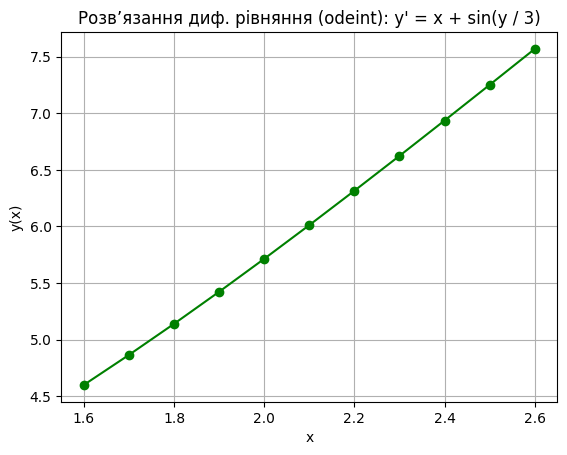

In [5]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Функція з умови
# y' = x + sin(y / 3)
def model(y, x):
    return x + np.sin(y / 3)

# Початкова умова
y0 = 4.6

# Межі відрізка
a, b = 1.6, 2.6

# Крок
h = 0.1

n = int((b - a) / h)

# Масив x
x = np.array([a + i * h for i in range(n + 1)])

# Розв’язання рівняння
y = odeint(model, y0, x)

# Округлення
y_rounded = np.around(y.flatten(), 4)

# Виведення результатів
print('x =', x)
print()
print('y =', y_rounded)

# Побудова графіка
plt.plot(
    x,
    y,
    marker='o',
    color='green'
)

plt.xlabel('x')
plt.ylabel('y(x)')

plt.title(
    "Розв’язання диф. рівняння (odeint): y' = x + sin(y / 3)"
)

plt.grid()

plt.show()

#Використання scipy.integrate.solve_ivp
Функція solve_ivp є більш сучасним і гнучким способом розв'язання ODE, ніж odeint. Вона також дозволяє використовувати різні методи інтегрування.

x = [1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5 2.6]

y = [4.6    4.865  5.1395 5.4227 5.7137 6.0113 6.3148 6.623  6.9352 7.2503
 7.5676]


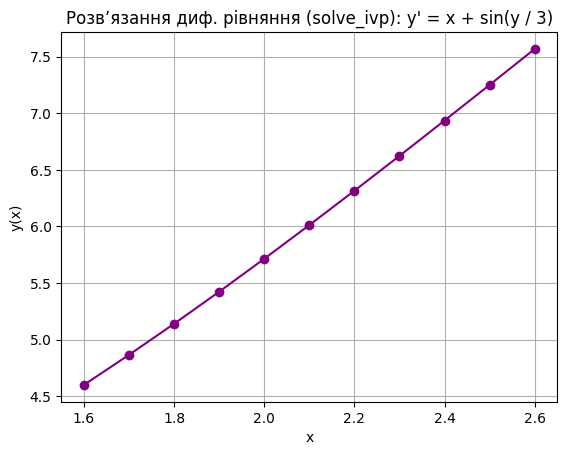

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Функція з умови
# y' = x + sin(y / 3)
def model(x, y):
    return x + np.sin(y / 3)

# Початкова умова
y0 = [4.6]

# Межі відрізка
a, b = 1.6, 2.6

# Крок
h = 0.1

n = int((b - a) / h)

# Масив x
x = np.array([a + i * h for i in range(n + 1)])

# Розв’язання рівняння
sol = solve_ivp(
    model,
    [a, b],
    y0,
    t_eval=x
)

# Виведення результатів
print('x =', sol.t)
print()
print('y =', np.around(sol.y[0], 4))

# Побудова графіка
plt.plot(
    sol.t,
    sol.y[0],
    marker='o',
    color='purple'
)

plt.xlabel('x')
plt.ylabel('y(x)')

plt.title(
    "Розв’язання диф. рівняння (solve_ivp): y' = x + sin(y / 3)"
)

plt.grid()

plt.show()